In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [ ]:
iris = load_iris()

In [ ]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


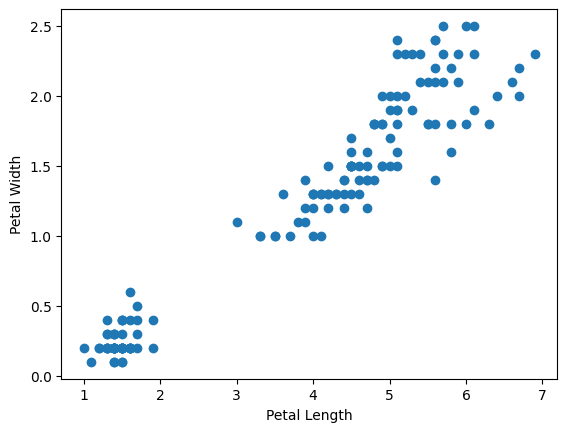

In [ ]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

In [ ]:
km = KMeans(n_clusters=2)
y_predicted = km.fit_predict(df)

# Add cluster column
df['cluster'] = y_predicted

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


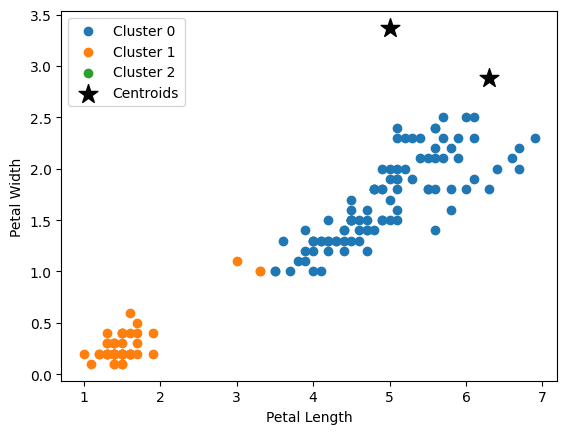

In [ ]:
plt.scatter(df[df.cluster==0]['petal length (cm)'],
            df[df.cluster==0]['petal width (cm)'],
            label='Cluster 0')

plt.scatter(df[df.cluster==1]['petal length (cm)'],
            df[df.cluster==1]['petal width (cm)'],
            label='Cluster 1')

plt.scatter(df[df.cluster==2]['petal length (cm)'],
            df[df.cluster==2]['petal width (cm)'],
            label='Cluster 2')

# Centroids
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            color='black',
            marker='*',
            s=200,
            label='Centroids')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.show()

In [ ]:
scaler = MinMaxScaler()

scaler.fit(df[['petal length (cm)']])
df['petal length (cm)'] = scaler.transform(df[['petal length (cm)']])

scaler.fit(df[['petal width (cm)']])
df['petal width (cm)'] = scaler.transform(df[['petal width (cm)']])

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5           0.067797          0.041667   
1                4.9               3.0           0.067797          0.041667   
2                4.7               3.2           0.050847          0.041667   
3                4.6               3.1           0.084746          0.041667   
4                5.0               3.6           0.067797          0.041667   

   cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


In [ ]:
km = KMeans(n_clusters=2)
y_predicted = km.fit_predict(df[['petal length (cm)', 'petal width (cm)']])

df['cluster'] = y_predicted

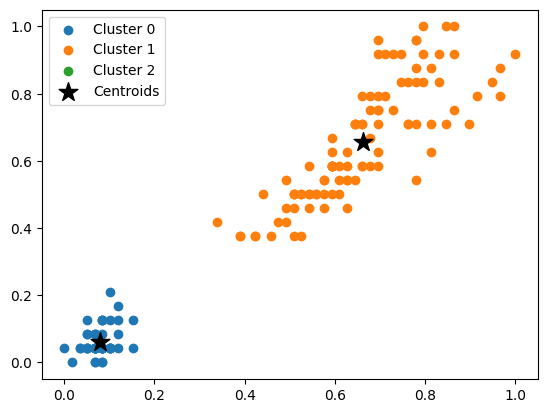

In [ ]:
plt.scatter(df[df.cluster==0]['petal length (cm)'],
            df[df.cluster==0]['petal width (cm)'],
            label='Cluster 0')

plt.scatter(df[df.cluster==1]['petal length (cm)'],
            df[df.cluster==1]['petal width (cm)'],
            label='Cluster 1')

plt.scatter(df[df.cluster==2]['petal length (cm)'],
            df[df.cluster==2]['petal width (cm)'],
            label='Cluster 2')

# Centroids
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            color='black',
            marker='*',
            s=200,
            label='Centroids')

plt.legend()
plt.show()

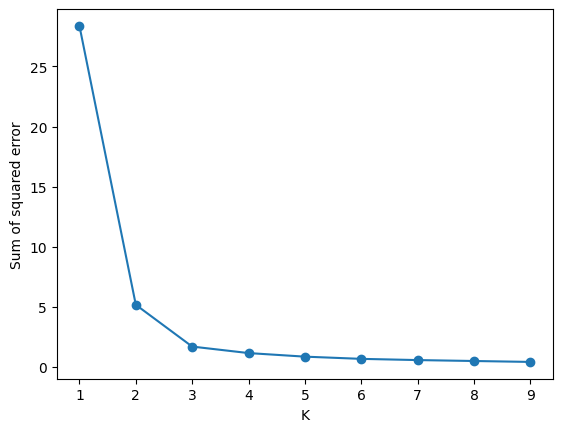

In [ ]:
sse = []

k_rng = range(1,10)

for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['petal length (cm)', 'petal width (cm)']])
    sse.append(km.inertia_)

plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse, marker='o')
plt.show()

In [ ]:
print(km.inertia_)

0.42544198335229505
